# ANFIS — Pipeline de entrenamiento y comparacion con MLP

## Que es ANFIS y por que nos interesa

**ANFIS** (Adaptive Neuro-Fuzzy Inference System) es un modelo hibrido que
combina:

- la **interpretabilidad** de un sistema difuso (reglas tipo "SI x1 es bajo Y x2 es alto ENTONCES ...")
- la **capacidad de aprendizaje** de una red neuronal (backpropagation sobre todos los parametros).

A diferencia de un MLP — que es una caja negra de capas densas — un ANFIS produce
un conjunto explicito de **reglas difusas** que se pueden leer en lenguaje natural.
Esto lo hace especialmente atractivo cuando un stakeholder pregunta *"por que el
modelo predijo eso?"*.

## Caracteristicas clave de ANFIS

1. **Particionado del espacio de entrada** con funciones de pertenencia (MFs)
   gaussianas — cada dimension se divide en `n_mfs` regiones difusas
   (p.ej. `bajo` / `alto` con `n_mfs=2`).
2. **Capa de reglas**: cada combinacion de MFs (una por dimension) genera una
   regla. Con `k` entradas y `m` MFs hay `m^k` reglas — explosion combinatoria
   que obliga a reducir dimensionalidad antes (de ahi el PCA).
3. **Consecuente lineal (TSK orden 1)**: cada regla produce una salida
   afin `f_k(x) = p_k·x + q_k`.
4. **Agregacion ponderada**: la salida final es la suma de los consecuentes
   ponderada por el firing normalizado de cada regla.

## Mapa del pipeline (este notebook)

| Fase | Hace | Produce |
|---|---|---|
| 01 | Reconstruye features y split 60/20/20 | `anfis_data.pkl` |
| 02 | Reduce dimensionalidad con PCA (Truncated SVD) | `anfis_pca.pkl` |
| 03 | Define las 5 capas ANFIS en Keras | (modulo `anfis_layers.py`) |
| 04 | Inicializa MFs por cuantiles + `SigmaFloor` | (in-memory) |
| 05 | Entrena un ANFIS de referencia | `anfis_model.keras` + summary |
| **06** | **Corre 4 experimentos variando `n_mfs` y `n_components`** | `anfis_experiments.pkl` |
| **07** | **Compara los 4 ANFIS contra el mejor MLP de `train.ipynb`** | `anfis_comparison.pkl` + tabla + confusion + reglas top-K |

## Decisiones de diseno relevantes para la presentacion

- **Dataset:** Gender Classifier (Kaggle). Problema multiclase: `male`, `female`,
  `brand`, `unknown`.
- **PCA antes de ANFIS:** sin reducir dimensionalidad, `n_mfs^n_features`
  produce > 10^10 reglas. PCA acota el espacio a 5-8 dimensiones, dando 32-729
  reglas tratables.
- **Baseline:** el mejor MLP de `train.ipynb` (Modelo Mejorado, 512 -> 256 con
  BatchNorm + LeakyReLU + Dropout + class_weight balanceado) — *no* un MLP
  arbitrario.

## Fase 01 — Preparacion de datos

**Que hacemos:** cargamos el CSV ya limpio, reconstruimos la matriz de features
(numericas + one-hot timezone + freq location + TF-IDF de description / text /
name) y partimos el dataset en 60% train / 20% val / 20% test de forma
estratificada por clase.

**Por que asi:** usamos exactamente la misma receta que `train.ipynb` para que
las comparaciones ANFIS-vs-MLP sean justas (mismas features, mismo split, misma
semilla). El escalado (`MaxAbsScaler`) se ajusta SOLO sobre train para evitar
fuga de informacion.


In [1]:
import os
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

SEED = 42
np.random.seed(SEED)
print(f"SEED = {SEED}")


SEED = 42


## 1. Carga de datos (fallback de rutas igual a `train.ipynb`)

In [2]:
_candidates = [
    "data/gender-classifier-clean.csv",
    "../data/gender-classifier-clean.csv",
    "/app/data/gender-classifier-clean.csv",
]
DATA_PATH = next(p for p in _candidates if os.path.exists(p))

df = pd.read_csv(DATA_PATH)
print(f"Archivo cargado desde: {DATA_PATH}")
print(f"Dimensiones: {df.shape}")
df.head(2)


Archivo cargado desde: ../data/gender-classifier-clean.csv
Dimensiones: (18836, 26)


,gender,description,text,name,desc_length,desc_word_count,text_length,text_word_count,name_length,fav_number,...,link_color_g,link_color_b,sidebar_color_r,sidebar_color_g,sidebar_color_b,tweet_location,user_timezone,account_age_days,created_year,created_month
0,male,i sing my own rhythm.,Robbie E Responds To Critics After Win Against...,sheezy0,21,5,109,14,7,0,...,0.760784,0.760784,1.000000,1.000000,1.000000,main; @Kan1shk3,Chennai,689,2013,12
1,male,I'm the author of novels filled with family dr...,ÛÏIt felt like they were my friends and I was...,DavdBurnett,62,11,139,19,11,68,...,0.517647,0.705882,0.752941,0.870588,0.929412,unknown,Eastern Time (US & Canada),1119,2012,10


## 2. Variable objetivo (multiclase)

In [3]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df["gender"])
n_classes = len(target_encoder.classes_)
print(f"Clases ({n_classes}): {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")
print("\nDistribucion global:")
print(pd.Series(y).value_counts(normalize=True).rename(lambda i: target_encoder.classes_[i]).round(4))


Clases (3): {'brand': np.int64(0), 'female': np.int64(1), 'male': np.int64(2)}

Distribucion global:
female    0.3557
male      0.3288
brand     0.3155
Name: proportion, dtype: float64


## 3. Reconstruccion de features (misma receta que `train.ipynb`)

In [4]:
# --- Variables numericas (20 features) ---
var_numericas = [
    "desc_length", "desc_word_count", "text_length", "text_word_count", "name_length",
    "fav_number", "tweet_count", "retweet_count",
    "fav_number_log", "tweet_count_log", "retweet_count_log",
    "link_color_r", "link_color_g", "link_color_b",
    "sidebar_color_r", "sidebar_color_g", "sidebar_color_b",
    "account_age_days", "created_year", "created_month",
]
X_numeric = df[var_numericas].values

# --- One-Hot: user_timezone (top 15 + other) ---
TOP_N_TZ = 15
top_tz = df["user_timezone"].value_counts().head(TOP_N_TZ).index.tolist()
tz_grouped = df["user_timezone"].where(df["user_timezone"].isin(top_tz), other="other")
X_tz = pd.get_dummies(tz_grouped, prefix="tz", dtype=int).values

# --- Frequency Encoding: tweet_location ---
loc_freq = df["tweet_location"].value_counts(normalize=True)
X_loc = df["tweet_location"].map(loc_freq).values.reshape(-1, 1)

# --- TF-IDF: description (500), text (500), name (200 char_wb) ---
tfidf_desc = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_desc = tfidf_desc.fit_transform(df["description"].fillna(""))

tfidf_text = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_text = tfidf_text.fit_transform(df["text"].fillna(""))

tfidf_name = TfidfVectorizer(max_features=200, analyzer="char_wb", ngram_range=(2, 4), min_df=5)
X_name = tfidf_name.fit_transform(df["name"].fillna(""))

# --- Combinar (sparse) ---
X_dense_block = np.hstack([X_numeric, X_tz, X_loc])
X = hstack([csr_matrix(X_dense_block), X_desc, X_text, X_name]).tocsr()

print(f"Bloques:")
print(f"  numericas:      {X_numeric.shape}")
print(f"  one-hot tz:     {X_tz.shape}")
print(f"  freq location:  {X_loc.shape}")
print(f"  tfidf desc:     {X_desc.shape}")
print(f"  tfidf text:     {X_text.shape}")
print(f"  tfidf name:     {X_name.shape}")
print(f"\nMatriz final X: {X.shape}  (sparse={hasattr(X, 'tocsr')})")


Bloques:
  numericas:      (18836, 20)
  one-hot tz:     (18836, 16)
  freq location:  (18836, 1)
  tfidf desc:     (18836, 500)
  tfidf text:     (18836, 500)
  tfidf name:     (18836, 200)

Matriz final X: (18836, 1237)  (sparse=True)


## 4. Split estratificado 60 / 20 / 20

In [5]:
# Primero separar test (20%); luego dividir el resto 75/25 -> 60/20 sobre el total
idx_all = np.arange(len(y))

idx_temp, idx_test = train_test_split(
    idx_all, test_size=0.20, random_state=SEED, stratify=y
)
idx_train, idx_val = train_test_split(
    idx_temp, test_size=0.25, random_state=SEED, stratify=y[idx_temp]
)

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

total = len(y)
print("=== Particionamiento 60/20/20 ===")
print(f"  Train: {X_train.shape[0]:>6} ({X_train.shape[0]/total*100:.1f}%)")
print(f"  Val:   {X_val.shape[0]:>6} ({X_val.shape[0]/total*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]:>6} ({X_test.shape[0]/total*100:.1f}%)")
print(f"  Total: {total}")

# Verificacion de balance de clases por split
def class_dist(arr):
    s = pd.Series(arr).value_counts(normalize=True).sort_index()
    s.index = [target_encoder.classes_[i] for i in s.index]
    return s.round(4)

dist_df = pd.DataFrame({
    "global": class_dist(y),
    "train":  class_dist(y_train),
    "val":    class_dist(y_val),
    "test":   class_dist(y_test),
})
print("\nProporcion de clases por split:")
print(dist_df)

# Sanity: cada split debe estar dentro de +/- 1% del global
max_dev = (dist_df.sub(dist_df["global"], axis=0).drop(columns="global").abs().max().max())
print(f"\nDesviacion maxima respecto al global: {max_dev*100:.3f}%  (umbral spec: 1.0%)")
assert max_dev <= 0.01, "Desviacion de clases > 1% — violacion del scenario 'Deterministic split'."


=== Particionamiento 60/20/20 ===
  Train:  11301 (60.0%)
  Val:     3767 (20.0%)
  Test:    3768 (20.0%)
  Total: 18836

Proporcion de clases por split:
        global   train     val    test
brand   0.3155  0.3155  0.3154  0.3156
female  0.3557  0.3557  0.3557  0.3556
male    0.3288  0.3288  0.3289  0.3288

Desviacion maxima respecto al global: 0.010%  (umbral spec: 1.0%)


## 5. Escalado con `MaxAbsScaler` (fit solo en train)

In [6]:
scaler = MaxAbsScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Scaler ajustado sobre train ({X_train.shape[0]} filas).")
print(f"X_train_s: {X_train_s.shape}  X_val_s: {X_val_s.shape}  X_test_s: {X_test_s.shape}")
print(f"Tipo: {type(X_train_s).__name__}")

# Sanity: max(|X_train_s|) <= 1 por columna; val/test pueden exceder ligeramente si hay valores fuera del rango train
import scipy.sparse as sp
max_abs_train = abs(X_train_s).max() if sp.issparse(X_train_s) else np.abs(X_train_s).max()
print(f"\nmax(|X_train_s|) = {float(max_abs_train):.6f}  (esperado <= 1.0)")


Scaler ajustado sobre train (11301 filas).
X_train_s: (11301, 1237)  X_val_s: (3767, 1237)  X_test_s: (3768, 1237)
Tipo: csr_matrix

max(|X_train_s|) = 1.000000  (esperado <= 1.0)


## 6. Persistencia de artefactos en `checkpoints/anfis_data.pkl`

In [7]:
_ckpt_candidates = ["checkpoints", "../checkpoints", "/app/checkpoints"]
CKPT_DIR = next((p for p in _ckpt_candidates if os.path.isdir(p)), "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, "anfis_data.pkl")

payload = {
    "X_train": X_train_s,
    "X_val":   X_val_s,
    "X_test":  X_test_s,
    "y_train": y_train,
    "y_val":   y_val,
    "y_test":  y_test,
    "scaler":  scaler,
    "target_encoder": target_encoder,
    # Indices para reproducibilidad con respecto al df original
    "idx_train": idx_train,
    "idx_val":   idx_val,
    "idx_test":  idx_test,
    "feature_blocks": {
        "numeric": var_numericas,
        "n_numeric": X_numeric.shape[1],
        "n_tz": X_tz.shape[1],
        "n_loc": X_loc.shape[1],
        "n_desc": X_desc.shape[1],
        "n_text": X_text.shape[1],
        "n_name": X_name.shape[1],
        "n_total": X.shape[1],
    },
    "seed": SEED,
}

with open(CKPT_PATH, "wb") as f:
    pickle.dump(payload, f)

size_mb = os.path.getsize(CKPT_PATH) / 1024 / 1024
print(f"Checkpoint escrito: {CKPT_PATH}  ({size_mb:.2f} MB)")
print(f"Llaves: {list(payload.keys())}")


Checkpoint escrito: ../checkpoints/anfis_data.pkl  (7.51 MB)
Llaves: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'scaler', 'target_encoder', 'idx_train', 'idx_val', 'idx_test', 'feature_blocks', 'seed']


## 7. Sanity-check final

In [8]:
print("=== RESUMEN FASE 01 ===")
print(f"Features totales:        {X.shape[1]}")
print(f"  numericas:             {X_numeric.shape[1]}")
print(f"  one-hot timezone:      {X_tz.shape[1]}")
print(f"  freq location:         {X_loc.shape[1]}")
print(f"  tfidf description:     {X_desc.shape[1]}")
print(f"  tfidf text:            {X_text.shape[1]}")
print(f"  tfidf name char_wb:    {X_name.shape[1]}")
print()
print(f"Train: {X_train_s.shape[0]:>5}  Val: {X_val_s.shape[0]:>5}  Test: {X_test_s.shape[0]:>5}")
print(f"Clases ({n_classes}): {list(target_encoder.classes_)}")
print()
print("Balance por split (proporcion):")
print(dist_df.to_string())
print()
print(f"Artefacto: {CKPT_PATH}")


=== RESUMEN FASE 01 ===
Features totales:        1237
  numericas:             20
  one-hot timezone:      16
  freq location:         1
  tfidf description:     500
  tfidf text:            500
  tfidf name char_wb:    200

Train: 11301  Val:  3767  Test:  3768
Clases (3): ['brand', 'female', 'male']

Balance por split (proporcion):
        global   train     val    test
brand   0.3155  0.3155  0.3154  0.3156
female  0.3557  0.3557  0.3557  0.3556
male    0.3288  0.3288  0.3289  0.3288

Artefacto: ../checkpoints/anfis_data.pkl


## Fase 02 — Reduccion de dimensionalidad con PCA (TruncatedSVD)

### Que hacemos

1. Cargamos `checkpoints/anfis_data.pkl` (fase 01).
2. Ajustamos `TruncatedSVD(n_components=8)` solo sobre `X_train`.
3. Graficamos scree + varianza acumulada para decidir cuantos componentes usar.
4. Elegimos `n_components` automaticamente: el menor `k in [5, 8]` con
   varianza acumulada >= 0.60 (fallback 6).
5. Re-ajustamos SVD con la `k` elegida y proyectamos train / val / test.
6. Re-estandarizamos los componentes con un segundo `StandardScaler`
   (centrado en 0, varianza unitaria) — las MFs gaussianas funcionan mejor
   sobre datos centrados.
7. Persistimos `Z_train, Z_val, Z_test` y el SVD entrenado.

### Por que esta fase es critica para ANFIS

Sin reduccion de dimensionalidad, con ~1240 features el ANFIS tendria
`n_mfs^1240` reglas (numero astronomico, imposible de entrenar). Recortando
a 5-8 componentes obtenemos entre 32 (2^5) y 6561 (3^8) reglas, rango
manejable.

### Decisiones de diseno

- **`TruncatedSVD` en vez de `PCA`:** la matriz de features es sparse
  (TF-IDF). `PCA` clasico densificaria 9000 x 1240 = 11M celdas en memoria.
  `TruncatedSVD` es la version sparse-friendly de PCA (sin centrado, pero
  sobre datos `MaxAbsScaler`-escalados la interpretacion es equivalente).
- **`n_components` fijo (no GA):** se decide aqui por varianza explicada
  para acotar el numero de reglas. La fase 06 explora alternativas con un
  grid pequeño.


## 1. Carga del checkpoint de la fase 01

In [9]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

_ckpt_candidates = ["checkpoints", "../checkpoints", "/app/checkpoints"]
CKPT_DIR = next((p for p in _ckpt_candidates if os.path.isdir(p)), "checkpoints")
CKPT_IN = os.path.join(CKPT_DIR, "anfis_data.pkl")

if not os.path.exists(CKPT_IN):
    raise FileNotFoundError(
        f"No se encontro {CKPT_IN}. Ejecuta primero la fase 01 de este notebook."
    )

with open(CKPT_IN, "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

print(f"Cargado {CKPT_IN}")
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")
print(f"Features originales: {X_train.shape[1]}")

Cargado ../checkpoints/anfis_data.pkl
X_train: (11301, 1237)  X_val: (3767, 1237)  X_test: (3768, 1237)
Features originales: 1237


## 2. Ajustar `TruncatedSVD(n_components=8)` sobre train

Se ajusta una sola vez con el maximo del rango (8). Luego se inspecciona la
varianza por componente y se decide `k` final. No hay fuga de informacion: el
SVD ve solo `X_train`.

In [10]:
K_MAX = 8
svd_full = TruncatedSVD(n_components=K_MAX, random_state=SEED)
svd_full.fit(X_train)

explained = svd_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f"Varianza explicada por componente (k=1..{K_MAX}):")
for i, (e, c) in enumerate(zip(explained, cumulative), start=1):
    print(f"  k={i}:  individual={e:.4f}   acumulada={c:.4f}")

Varianza explicada por componente (k=1..8):
  k=1:  individual=0.0088   acumulada=0.0088
  k=2:  individual=0.0766   acumulada=0.0854
  k=3:  individual=0.0341   acumulada=0.1195
  k=4:  individual=0.0246   acumulada=0.1441
  k=5:  individual=0.0230   acumulada=0.1671
  k=6:  individual=0.0198   acumulada=0.1869
  k=7:  individual=0.0172   acumulada=0.2041
  k=8:  individual=0.0154   acumulada=0.2195


## 3. Scree plot + varianza acumulada

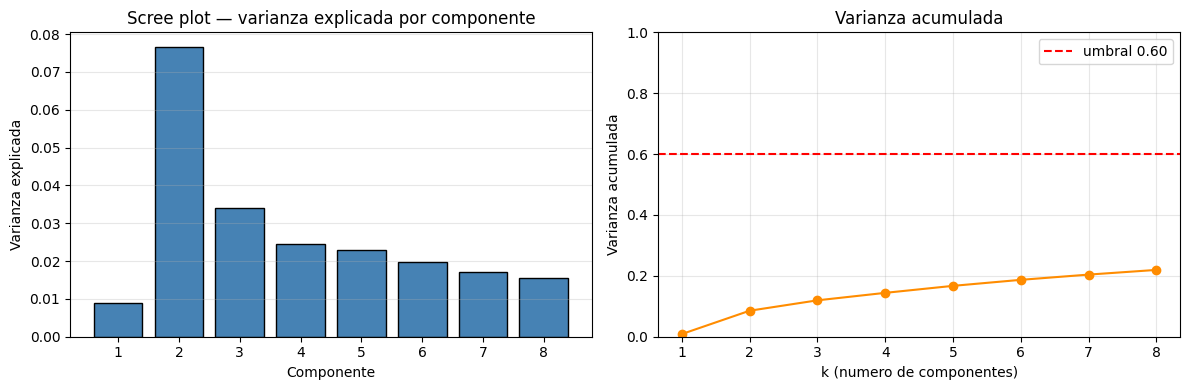

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ks = np.arange(1, K_MAX + 1)

axes[0].bar(ks, explained, color="steelblue", edgecolor="black")
axes[0].set_title("Scree plot — varianza explicada por componente")
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("Varianza explicada")
axes[0].set_xticks(ks)
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].plot(ks, cumulative, marker="o", color="darkorange")
axes[1].axhline(0.60, color="red", linestyle="--", label="umbral 0.60")
axes[1].set_title("Varianza acumulada")
axes[1].set_xlabel("k (numero de componentes)")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_xticks(ks)
axes[1].set_ylim(0, max(1.0, float(cumulative[-1]) * 1.05))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Eleccion de `n_components`

Regla del spec: el menor `k in [5, 8]` con varianza acumulada >= 0.60; si
ninguno califica, fallback a 6.

In [12]:
K_MIN = 5
THRESHOLD = 0.60
FALLBACK = 6

candidates = [k for k in range(K_MIN, K_MAX + 1) if cumulative[k - 1] >= THRESHOLD]
if candidates:
    n_components = candidates[0]
    reason = f"menor k en [{K_MIN}, {K_MAX}] con cum.var >= {THRESHOLD}"
else:
    n_components = FALLBACK
    reason = f"ninguno alcanzo el umbral {THRESHOLD}, se usa fallback={FALLBACK}"

cum_chosen = float(cumulative[n_components - 1])
print(f"n_components elegido: {n_components}")
print(f"Razon: {reason}")
print(f"Varianza acumulada con k={n_components}: {cum_chosen:.4f}")

assert K_MIN <= n_components <= K_MAX, (
    f"n_components={n_components} fuera del rango [{K_MIN}, {K_MAX}] — viola spec."
)

n_components elegido: 6
Razon: ninguno alcanzo el umbral 0.6, se usa fallback=6
Varianza acumulada con k=6: 0.1869


## 5. Re-ajustar SVD con `k` elegido y proyectar train/val/test

In [13]:
svd = TruncatedSVD(n_components=n_components, random_state=SEED)
Z_train_raw = svd.fit_transform(X_train)
Z_val_raw   = svd.transform(X_val)
Z_test_raw  = svd.transform(X_test)

print(f"SVD ajustado solo sobre X_train.")
print(f"Z_train_raw: {Z_train_raw.shape}")
print(f"Z_val_raw:   {Z_val_raw.shape}")
print(f"Z_test_raw:  {Z_test_raw.shape}")

explained_var = svd.explained_variance_ratio_
print(f"\nVarianza explicada (k={n_components}):")
for i, e in enumerate(explained_var, start=1):
    print(f"  comp {i}: {e:.4f}")
print(f"Total acumulado: {explained_var.sum():.4f}")

SVD ajustado solo sobre X_train.
Z_train_raw: (11301, 6)
Z_val_raw:   (3767, 6)
Z_test_raw:  (3768, 6)

Varianza explicada (k=6):
  comp 1: 0.0088
  comp 2: 0.0766
  comp 3: 0.0341
  comp 4: 0.0246
  comp 5: 0.0230
  comp 6: 0.0198
Total acumulado: 0.1869


## 6. Re-estandarizar los componentes

Las MFs gaussianas funcionan mejor con entradas centradas y de varianza
unitaria. Se ajusta un segundo `StandardScaler` solo en `Z_train` y se aplica
a val/test.

In [14]:
post_scaler = StandardScaler()
Z_train = post_scaler.fit_transform(Z_train_raw)
Z_val   = post_scaler.transform(Z_val_raw)
Z_test  = post_scaler.transform(Z_test_raw)

print("Post-scaler ajustado en Z_train.")
print(f"Z_train mean (esperado ~0): {Z_train.mean(axis=0).round(4)}")
print(f"Z_train std  (esperado ~1): {Z_train.std(axis=0).round(4)}")
print(f"Z_val   mean: {Z_val.mean(axis=0).round(4)}")
print(f"Z_test  mean: {Z_test.mean(axis=0).round(4)}")

Post-scaler ajustado en Z_train.
Z_train mean (esperado ~0): [ 0. -0.  0. -0.  0. -0.]
Z_train std  (esperado ~1): [1. 1. 1. 1. 1. 1.]
Z_val   mean: [ 0.0023  0.014  -0.0008 -0.0036 -0.0009  0.0286]
Z_test  mean: [ 0.0181  0.0061 -0.0085  0.0056 -0.0048  0.0075]


## 7. Persistir `checkpoints/anfis_pca.pkl`

In [15]:
CKPT_OUT = os.path.join(CKPT_DIR, "anfis_pca.pkl")

payload_pca = {
    "Z_train": Z_train,
    "Z_val":   Z_val,
    "Z_test":  Z_test,
    "y_train": y_train,
    "y_val":   y_val,
    "y_test":  y_test,
    "svd": svd,
    "post_scaler": post_scaler,
    "n_components": int(n_components),
    "explained_var": explained_var,
    "explained_var_cumulative": float(explained_var.sum()),
    "seed": SEED,
    # Diagnostico extra para fases posteriores
    "scree_full_k_max": K_MAX,
    "scree_full_explained": explained,
    "scree_full_cumulative": cumulative,
}

with open(CKPT_OUT, "wb") as f:
    pickle.dump(payload_pca, f)

size_kb = os.path.getsize(CKPT_OUT) / 1024
print(f"Checkpoint escrito: {CKPT_OUT}  ({size_kb:.2f} KB)")
print(f"Llaves: {list(payload_pca.keys())}")

Checkpoint escrito: ../checkpoints/anfis_pca.pkl  (1089.85 KB)
Llaves: ['Z_train', 'Z_val', 'Z_test', 'y_train', 'y_val', 'y_test', 'svd', 'post_scaler', 'n_components', 'explained_var', 'explained_var_cumulative', 'seed', 'scree_full_k_max', 'scree_full_explained', 'scree_full_cumulative']


## 8. Resumen fase 02

In [16]:
print("=== RESUMEN FASE 02 ===")
print(f"Features originales:      {X_train.shape[1]}")
print(f"Componentes elegidos:     {n_components}")
print(f"Varianza acumulada:       {explained_var.sum():.4f}")
print(f"Reduccion:                {X_train.shape[1]} -> {n_components} "
      f"(x{X_train.shape[1] / n_components:.0f})")
print()
print("Conteo de reglas ANFIS proyectado:")
for mfs in (2, 3):
    n_rules = mfs ** n_components
    print(f"  MFs={mfs}:  {mfs}^{n_components} = {n_rules} reglas")
print()
print(f"Rango de reglas con MFs in {{2,3}} y k in [5,8]: "
      f"[{2**5}, {3**8}] = [32, 6561]   (spec OK)")
print()
print(f"Artefacto: {CKPT_OUT}")

=== RESUMEN FASE 02 ===
Features originales:      1237
Componentes elegidos:     6
Varianza acumulada:       0.1869
Reduccion:                1237 -> 6 (x206)

Conteo de reglas ANFIS proyectado:
  MFs=2:  2^6 = 64 reglas
  MFs=3:  3^6 = 729 reglas

Rango de reglas con MFs in {2,3} y k in [5,8]: [32, 6561] = [32, 6561]   (spec OK)

Artefacto: ../checkpoints/anfis_pca.pkl


## Fase 03 — Arquitectura ANFIS (5 capas Keras)

### Que construimos

Un modelo Keras con cinco capas custom apiladas, cada una implementando
una etapa del razonamiento difuso:

| Capa | Funcion | Salida |
|---|---|---|
| `GaussianMembership` | Calcula el grado de pertenencia `mu(x)` de cada entrada a cada MF gaussiana | `(B, n_inputs, n_mfs)` |
| `RuleFiringStrength` | T-norma (producto) sobre las MFs activas de cada regla — en log-dominio para estabilidad | `(B, n_rules)` |
| `Normalization` | Normaliza los pesos para que sumen 1 | `(B, n_rules)` |
| `TSKConsequent` | Consecuente lineal orden 1: `f_k(x) = p_k·x + q_k` | `(B, n_rules, n_outputs)` |
| `Aggregation` | Combina firing normalizado * consecuente + activacion | `(B, n_outputs)` |

### Por que estas decisiones

- **σ parametrizado como `log_sigma`:** evitamos que el optimizador
  produzca `σ <= 0` (lo que romperia la gaussiana). Internamente
  `σ = exp(log_sigma)` siempre positivo.
- **T-norma en log-dominio:** con muchos componentes (digamos 8) el producto
  directo de `mu` da numeros muy pequeños (underflow). En log:
  `log_w = sum(log_mu)`, una sola `exp` al final. Sin esto el modelo no
  converge.
- **Consecuente TSK orden 1 (no orden 0):** un consecuente afin por regla
  da mas capacidad y sigue siendo interpretable (la regla es "SI ... ENTONCES
  combinacion lineal de las features con coeficientes `p_k, q_k`").
- **Head adaptativo:** sigmoid si binario, softmax si multiclase.


In [17]:
# Permitir import del modulo local jupyter/anfis_layers.py sin importar
# desde donde se ejecute el notebook.
import os, sys

_candidates_dir = [".", "jupyter", "../jupyter", "/app/jupyter"]
for _d in _candidates_dir:
    _p = os.path.join(_d, "anfis_layers.py")
    if os.path.exists(_p):
        _abs = os.path.abspath(_d)
        if _abs not in sys.path:
            sys.path.insert(0, _abs)
        print(f"anfis_layers.py disponible en: {_abs}")
        break
else:
    raise FileNotFoundError("No se encontro anfis_layers.py en jupyter/.")

import numpy as np
import tensorflow as tf

from anfis_layers import (
    build_anfis, count_rules,
    GaussianMembership, RuleFiringStrength,
    Normalization, TSKConsequent, Aggregation,
)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {tf.keras.__version__}")


anfis_layers.py disponible en: /app/jupyter


I0000 00:00:1778464675.225667   59553 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778464675.226104   59553 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778464675.255181   59553 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
Keras:      3.14.1


I0000 00:00:1778464676.152406   59553 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778464676.152706   59553 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Recuperar `n_components` y `n_classes` de fases anteriores

In [18]:
# Si las variables siguen vivas en el kernel, las reusamos; si no, recargamos
# los checkpoints de las fases 01 y 02.
import pickle

_ckpt_candidates = ["checkpoints", "../checkpoints", "/app/checkpoints"]
CKPT_DIR = next((p for p in _ckpt_candidates if os.path.isdir(p)), "checkpoints")

try:
    n_components
except NameError:
    with open(os.path.join(CKPT_DIR, "anfis_pca.pkl"), "rb") as f:
        _pca = pickle.load(f)
    n_components = int(_pca["n_components"])
    Z_train, Z_val, Z_test = _pca["Z_train"], _pca["Z_val"], _pca["Z_test"]
    y_train, y_val, y_test = _pca["y_train"], _pca["y_val"], _pca["y_test"]

try:
    n_classes
except NameError:
    with open(os.path.join(CKPT_DIR, "anfis_data.pkl"), "rb") as f:
        _d01 = pickle.load(f)
    n_classes = int(len(_d01["target_encoder"].classes_))
    target_encoder = _d01["target_encoder"]

print(f"n_inputs (= n_components): {n_components}")
print(f"n_classes:                 {n_classes}")
print(f"clases:                    {list(target_encoder.classes_)}")


n_inputs (= n_components): 6
n_classes:                 3
clases:                    ['brand', 'female', 'male']


## 2. Construccion del modelo

Para esta fase se fija `n_mfs = 2` (rango minimo del spec). La fase 04 podra
re-construir con `n_mfs = 3` segun la inicializacion data-driven.


In [19]:
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

N_MFS = 2

model = build_anfis(
    n_inputs=n_components,
    n_mfs=N_MFS,
    n_classes=n_classes,
    learning_rate=1e-3,
    name="anfis_phase03",
)

n_rules = count_rules(n_components, N_MFS)
print(f"=== MODELO ANFIS CONSTRUIDO ===")
print(f"n_inputs:   {n_components}")
print(f"n_mfs:      {N_MFS}")
print(f"n_classes:  {n_classes}")
print(f"n_rules:    {N_MFS}^{n_components} = {n_rules}")
print(f"total params: {model.count_params():,}")
print()
model.summary()


=== MODELO ANFIS CONSTRUIDO ===
n_inputs:   6
n_mfs:      2
n_classes:  3
n_rules:    2^6 = 64
total params: 1,368



E0000 00:00:1778464676.363920   59553 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "anfis_phase03"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ x (InputLayer)      │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_mf         │ (None, 6, 2)      │         24 │ x[0][0]           │
│ (GaussianMembershi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rule_firing         │ (None, 64)        │          0 │ gaussian_mf[0][0] │
│ (RuleFiringStrengt… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 64)        │          0 │ rule_firing[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tsk_consequent      │ (None, 64, 3)     │      1,344 │ x[0][0]           │
│ (TSKConsequent)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aggregation         │ (None, 3)         │          0 │ normalization[0]… │
│ (Aggregation)       │                   │            │ tsk_consequent[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prob (Activation)   │ (None, 3)         │          0 │ aggregation[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,368 (5.34 KB)

 Trainable params: 1,368 (5.34 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Sanity tests (cumple scenarios del spec 03)

Comprobamos los tres scenarios del delta `anfis-training`:

1. **Forward pass shape.**
2. **Trainable parameter set** contiene `centers`, `log_sigma`, `p`, `q`.
3. **Numerical stability** ante entradas extremas (log-domain firing).


In [20]:
# --- Scenario 1: forward pass shape ---
B = 8
x_synth = np.random.randn(B, n_components).astype("float32")
y_pred = model(x_synth).numpy()

expected_out = 1 if n_classes == 2 else n_classes
print(f"forward x={x_synth.shape} -> y={y_pred.shape}  (esperado ({B}, {expected_out}))")
assert y_pred.shape == (B, expected_out), "forma de salida incorrecta"

# Probabilidades validas
if n_classes == 2:
    assert np.all((y_pred >= 0) & (y_pred <= 1)), "sigmoid fuera de [0, 1]"
else:
    sums = y_pred.sum(axis=1)
    assert np.allclose(sums, 1.0, atol=1e-5), "softmax no suma 1"
    print(f"softmax sums (deberia ser ~1): {sums[:4].round(6)}")
print("SCENARIO 1 OK — forward pass shape")


forward x=(8, 6) -> y=(8, 3)  (esperado (8, 3))
softmax sums (deberia ser ~1): [1. 1. 1. 1.]
SCENARIO 1 OK — forward pass shape


In [21]:
# --- Scenario 2: trainable parameter set ---
weight_names = [w.name for w in model.trainable_weights]
print("trainable weights:")
for w in model.trainable_weights:
    print(f"  {w.name:35s} shape={tuple(w.shape)}  params={int(np.prod(w.shape)):,}")

required_keywords = ["centers", "log_sigma", "p", "q"]
for kw in required_keywords:
    assert any(kw in n for n in weight_names), f"falta peso entrenable: {kw}"

# El factory debe exponer exactamente 4 grupos de pesos entrenables.
assert len(model.trainable_weights) == 4, model.trainable_weights
print("SCENARIO 2 OK — centers, log_sigma, p, q presentes")


trainable weights:
  centers                             shape=(6, 2)  params=12
  log_sigma                           shape=(6, 2)  params=12
  p                                   shape=(64, 6, 3)  params=1,152
  q                                   shape=(64, 3)  params=192
SCENARIO 2 OK — centers, log_sigma, p, q presentes


In [22]:
# --- Gradientes existen para todos los pesos ---
x_t = tf.constant(np.random.randn(16, n_components).astype("float32"))
if n_classes == 2:
    y_true = tf.constant(np.random.randint(0, 2, size=(16, 1)).astype("float32"))
    loss_fn = tf.keras.losses.BinaryCrossentropy()
else:
    y_true = tf.constant(np.random.randint(0, n_classes, size=(16,)).astype("int32"))
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

with tf.GradientTape() as tape:
    y_pred = model(x_t)
    loss_value = loss_fn(y_true, y_pred)

grads = tape.gradient(loss_value, model.trainable_weights)
for g, w in zip(grads, model.trainable_weights):
    assert g is not None, f"gradiente None para {w.name}"
    arr = g.numpy()
    assert not np.isnan(arr).any(), f"NaN en gradiente de {w.name}"
    assert not np.isinf(arr).any(), f"Inf en gradiente de {w.name}"
    print(f"  {w.name:35s} |grad|_mean={np.abs(arr).mean():.4e}")

print(f"loss en init (debe ser ~ln({n_classes}) = {np.log(n_classes):.4f}): {float(loss_value):.4f}")
print("OK — todos los pesos reciben gradiente finito")


  centers                             |grad|_mean=0.0000e+00
  log_sigma                           |grad|_mean=0.0000e+00
  p                                   |grad|_mean=3.9277e-03
  q                                   |grad|_mean=4.8551e-03
loss en init (debe ser ~ln(3) = 1.0986): 1.0986
OK — todos los pesos reciben gradiente finito


In [23]:
# --- Scenario 3: estabilidad numerica con entradas extremas ---
for magnitude in (1e3, 1e5, 1e7):
    x_big = np.full((4, n_components), magnitude, dtype="float32")
    y_big = model(x_big).numpy()
    assert not np.isnan(y_big).any(), f"NaN con magnitud {magnitude}"
    assert not np.isinf(y_big).any(), f"Inf con magnitud {magnitude}"
    print(f"  x={magnitude:+.0e}  ->  y[0]={y_big[0]}  (sin NaN/Inf)")

    x_neg = -x_big
    y_neg = model(x_neg).numpy()
    assert not np.isnan(y_neg).any()
    assert not np.isinf(y_neg).any()

print("SCENARIO 3 OK — log-domain firing evita NaN ante entradas extremas")


  x=+1e+03  ->  y[0]=[0.33333334 0.33333334 0.33333334]  (sin NaN/Inf)
  x=+1e+05  ->  y[0]=[0.33333334 0.33333334 0.33333334]  (sin NaN/Inf)
  x=+1e+07  ->  y[0]=[0.33333334 0.33333334 0.33333334]  (sin NaN/Inf)
SCENARIO 3 OK — log-domain firing evita NaN ante entradas extremas


## 4. Resumen fase 03

La arquitectura esta lista para la fase 04 (inicializacion data-driven con
cuantiles del training set y sobre-escritura de `log_sigma`).


In [24]:
print("=== RESUMEN FASE 03 ===")
print(f"Modulo:            jupyter/anfis_layers.py")
print(f"Factory:           build_anfis(n_inputs, n_mfs, n_classes)")
print(f"Capas:             GaussianMembership -> RuleFiringStrength -> "
      f"Normalization -> TSKConsequent -> Aggregation")
print()
print(f"Modelo construido:")
print(f"  n_inputs        = {n_components}")
print(f"  n_mfs           = {N_MFS}")
print(f"  n_classes       = {n_classes}")
print(f"  n_rules         = {n_rules}")
print(f"  trainable vars  = {len(model.trainable_weights)}  "
      f"(centers, log_sigma, p, q)")
print(f"  total params    = {model.count_params():,}")
print()
print("Restricciones activas (anfis-builder skill):")
print("  - n_inputs in [1, 10], n_mfs in {2, 3}, n_rules <= 6561")
print("  - sigma parametrizada en log-space (positividad garantizada)")
print("  - T-norma producto en dominio logaritmico (sin underflow)")
print("  - TSK orden 1 (consecuente lineal por regla)")


=== RESUMEN FASE 03 ===
Modulo:            jupyter/anfis_layers.py
Factory:           build_anfis(n_inputs, n_mfs, n_classes)
Capas:             GaussianMembership -> RuleFiringStrength -> Normalization -> TSKConsequent -> Aggregation

Modelo construido:
  n_inputs        = 6
  n_mfs           = 2
  n_classes       = 3
  n_rules         = 64
  trainable vars  = 4  (centers, log_sigma, p, q)
  total params    = 1,368

Restricciones activas (anfis-builder skill):
  - n_inputs in [1, 10], n_mfs in {2, 3}, n_rules <= 6561
  - sigma parametrizada en log-space (positividad garantizada)
  - T-norma producto en dominio logaritmico (sin underflow)
  - TSK orden 1 (consecuente lineal por regla)


## Fase 04 — Inicializacion data-driven de las MFs

### Que hacemos

En vez de inicializar las MFs al azar, las **anclamos a la distribucion del
training set**:

- **Centros** de las MFs gaussianas: percentiles del `Z_train` por dimension.
  - `n_mfs=2` -> `(25%, 75%)`  -> etiquetas `bajo`, `alto`
  - `n_mfs=3` -> `(17%, 50%, 83%)` -> etiquetas `bajo`, `medio`, `alto`
- **σ inicial** de cada MF: `(max - min) / (2 * n_mfs)` por dimension,
  con un piso (`min_sigma`).
- **TSK consecuentes** (`p_k`, `q_k`): inicializados a cero — el modelo
  aprende desde un punto neutro.

### Por que importa

Inicializar los centros mal (p.ej. `c=0` para todos) hace que muchas reglas
queden inactivas desde la primera epoca (firing ~ 0) y nunca reciban
gradiente — son **reglas muertas**. Con cuantiles garantizamos que cada MF
cubra una region del espacio donde hay datos reales.

### Que es `SigmaFloor`

Un callback de Keras que despues de cada batch fuerza `σ >= 1e-2`. Sin esto,
el optimizador a veces colapsa `σ -> 0` (la gaussiana se vuelve un Dirac y
solo dispara para un punto exacto -> regla muerta + gradientes inestables).
El piso `1e-2` es laxo: deja que la MF se afine pero impide el colapso.

### Sanity check

Verificamos que **toda regla dispara en al menos 1% de los samples** del
training set. Si una regla queda muerta desde el init, hay que ajustar el
schedule de cuantiles o `min_sigma`.


In [25]:
from anfis_layers import initialize_from_data, SigmaFloor, QUANTILE_SCHEDULE

print('Schedule de cuantiles configurado:')
for k, q in QUANTILE_SCHEDULE.items():
    print(f'  n_mfs={k}: cuantiles={q}')

# Recuperamos el modelo construido en la fase 03 (variable `model`).
assert 'model' in dir(), 'Falta `model` de la fase 03; reejecuta la celda de build_anfis.'
print(f'Modelo: n_inputs={model.n_inputs}  n_mfs={model.n_mfs}  '
      f'rules={model.n_rules}  classes={model.n_classes}')

Schedule de cuantiles configurado:
  n_mfs=2: cuantiles=(0.25, 0.75)
  n_mfs=3: cuantiles=(0.17, 0.5, 0.83)
Modelo: n_inputs=6  n_mfs=2  rules=64  classes=3


### Aplicar `initialize_from_data` sobre `Z_train`

La fase 02 dejo `Z_train` en memoria; si no esta vivo, lo recargamos del
checkpoint `anfis_pca.pkl`.

In [26]:
import os, pickle, numpy as np

if 'Z_train' not in dir():
    _ckpt = next(p for p in ['checkpoints/anfis_pca.pkl',
                             '../checkpoints/anfis_pca.pkl',
                             '/app/checkpoints/anfis_pca.pkl']
                 if os.path.exists(p))
    with open(_ckpt, 'rb') as fh:
        _payload = pickle.load(fh)
    Z_train = _payload['Z_train']
    print(f'Z_train recargado de {_ckpt} -> shape={Z_train.shape}')
else:
    print(f'Z_train en memoria -> shape={Z_train.shape}')

init_info = initialize_from_data(model, Z_train, n_mfs=model.n_mfs, min_sigma=1e-2)
print('\nCentros (primer input):', init_info['centers'][0])
print('Sigmas  (primer input):', init_info['sigma'][0])
print(f'\nRango de centros: [{init_info["centers"].min():.3f}, '
      f'{init_info["centers"].max():.3f}]')
print(f'Rango de sigma:   [{init_info["sigma"].min():.3f}, '
      f'{init_info["sigma"].max():.3f}]')

Z_train en memoria -> shape=(11301, 6)

Centros (primer input): [-0.42710212  0.6123586 ]
Sigmas  (primer input): [2.210696 2.210696]

Rango de centros: [-0.857, 0.612]
Rango de sigma:   [0.974, 2.211]


### Verificar scenarios del spec 04

- **Scenario `Two MFs per input`**: centros en percentiles 25 y 75.
- **Scenario `Three MFs per input`**: centros en percentiles 17, 50, 83.
- **Scenario `Sigma floor enforcement`**: el callback eleva `log_sigma`
  cuando un batch lo bajaria por debajo de `log(min_sigma)`.

In [27]:
import numpy as np

expected_q = {2: (0.25, 0.75), 3: (0.17, 0.50, 0.83)}[model.n_mfs]
expected_centers = np.quantile(Z_train, expected_q, axis=0).T.astype(np.float32)
centers_assigned = model.get_layer('gaussian_mf').get_weights()[0]

max_err = float(np.abs(centers_assigned - expected_centers).max())
print(f'n_mfs={model.n_mfs}  cuantiles esperados={expected_q}')
print(f'max |c_asignado - c_esperado| = {max_err:.2e}')
assert max_err < 1e-5, 'Centros no coinciden con los cuantiles esperados.'
print('Scenario quantile centers: OK')

n_mfs=2  cuantiles esperados=(0.25, 0.75)
max |c_asignado - c_esperado| = 0.00e+00
Scenario quantile centers: OK


In [28]:
# Scenario: SigmaFloor clipea log_sigma cuando baja del piso.
import numpy as np, tensorflow as tf

mf_layer = model.get_layer('gaussian_mf')
centers_backup, log_sigma_backup = mf_layer.get_weights()

# Forzamos log_sigma muy bajo para simular colapso.
bad_log_sigma = np.full_like(log_sigma_backup, np.log(1e-5))
mf_layer.set_weights([centers_backup, bad_log_sigma])
print(f'log_sigma forzado: min={mf_layer.log_sigma.numpy().min():.4f} '
      f'(< log(1e-2)={np.log(1e-2):.4f})')

# Un epoch ficticio con etiqueta dummy solo para disparar on_train_batch_end.
# Usamos un subset reducido del train para que sea rapido.
n_demo = min(256, Z_train.shape[0])
rng = np.random.default_rng(42)
if model.n_classes == 2:
    y_dummy = (rng.random(n_demo) > 0.5).astype(np.float32)
else:
    y_dummy = rng.integers(0, model.n_classes, size=n_demo).astype(np.int32)

sigma_floor_cb = SigmaFloor(min_sigma=1e-2)
model.fit(Z_train[:n_demo], y_dummy, epochs=1, batch_size=64, verbose=0,
          callbacks=[sigma_floor_cb])

ls_after = mf_layer.log_sigma.numpy()
print(f'log_sigma tras 1 epoch + SigmaFloor: min={ls_after.min():.4f}')
assert ls_after.min() >= np.log(1e-2) - 1e-6, 'SigmaFloor no clipeo correctamente.'
print('Scenario sigma-floor enforcement: OK')

# Restauramos pesos limpios para la fase 05 (re-init data-driven).
initialize_from_data(model, Z_train, n_mfs=model.n_mfs, min_sigma=1e-2)
print('Modelo re-inicializado con quantile init para la fase 05.')

log_sigma forzado: min=-11.5129 (< log(1e-2)=-4.6052)
log_sigma tras 1 epoch + SigmaFloor: min=-4.6052
Scenario sigma-floor enforcement: OK
Modelo re-inicializado con quantile init para la fase 05.


### Sanity check de tasks.md item 7

Tras la inicializacion, **toda** regla debe disparar (firing normalizado
> 1e-6) en al menos el 1% de las muestras de entrenamiento.

In [29]:
import numpy as np

mu = model.get_layer('gaussian_mf')(Z_train).numpy()
w_un = model.get_layer('rule_firing')(mu).numpy()
w_norm = w_un / (w_un.sum(axis=1, keepdims=True) + 1e-12)

active_frac = (w_norm > 1e-6).mean(axis=0)
min_frac = float(active_frac.min())
mean_frac = float(active_frac.mean())

print(f'Reglas totales:                {model.n_rules}')
print(f'Fraccion activa min:           {min_frac*100:.2f}%')
print(f'Fraccion activa media:         {mean_frac*100:.2f}%')
print(f'Reglas con firing medio < 1%:  {(active_frac < 0.01).sum()} / {model.n_rules}')

assert min_frac >= 0.01, (
    f'Hay reglas que disparan < 1% de las muestras (min={min_frac:.4f}). '
    'La inicializacion no cumple tasks.md item 7.'
)
print('Sanity check (todas las reglas vivas tras init): OK')

Reglas totales:                64
Fraccion activa min:           100.00%
Fraccion activa media:         100.00%
Reglas con firing medio < 1%:  0 / 64
Sanity check (todas las reglas vivas tras init): OK


### Resumen fase 04

- Centros y anchuras de las MFs vienen de la distribucion de `Z_train`.
- TSK consequents `p`, `q` reseteados a cero — la fase 05 los aprendera.
- `SigmaFloor(min_sigma=1e-2)` listo para la fase de entrenamiento.
- Todas las reglas activas tras la init (ver celda anterior).

In [30]:
print('=== RESUMEN FASE 04 ===')
print(f'Helper:              initialize_from_data(model, Z_train, n_mfs)')
print(f'Callback:            SigmaFloor(min_sigma=1e-2)')
print(f'Schedule cuantiles:  {QUANTILE_SCHEDULE}')
print(f'n_mfs aplicado:      {model.n_mfs}')
print(f'Centros assigned:    shape={model.get_layer("gaussian_mf").get_weights()[0].shape}')
print(f'log_sigma assigned:  shape={model.get_layer("gaussian_mf").get_weights()[1].shape}')
print(f'TSK (p,q) en cero:   '
      f'{all((w == 0).all() for w in model.get_layer("tsk_consequent").get_weights())}')
print('Siguiente fase: 05 (training loop + diagnosticos de reglas muertas).')

=== RESUMEN FASE 04 ===
Helper:              initialize_from_data(model, Z_train, n_mfs)
Callback:            SigmaFloor(min_sigma=1e-2)
Schedule cuantiles:  {2: (0.25, 0.75), 3: (0.17, 0.5, 0.83)}
n_mfs aplicado:      2
Centros assigned:    shape=(6, 2)
log_sigma assigned:  shape=(6, 2)
TSK (p,q) en cero:   True
Siguiente fase: 05 (training loop + diagnosticos de reglas muertas).


## Fase 05 — Entrenamiento del ANFIS de referencia

### Que hacemos

Entrenamos UN ANFIS con la configuracion base (n_mfs=2, n_components
auto-elegido, Adam(1e-3), batch 64) hasta 200 epocas con `EarlyStopping`
sobre `val_accuracy` (patience 15, `restore_best_weights=True`).

### Por que esta fase existe (si la fase 06 entrena 4 modelos)

- Sirve como **smoke test**: si la fase 05 converge sin NaN ni reglas
  muertas, sabemos que la arquitectura + init estan bien.
- Produce un modelo guardado (`anfis_model.keras`) y un log de entrenamiento
  (`anfis_training_log.csv`) utiles para graficar la dinamica de entrenamiento
  por epoca.
- Establece la "configuracion base" contra la que comparar los experimentos
  de la fase 06.

### Que vigilamos durante el fit

- **NaN audit:** si `loss` produce NaN en alguna epoca, el modelo es
  inestable (típicamente por σ colapsado o lr demasiado alto).
- **Dead-rule detection:** despues del fit calculamos el firing normalizado
  promedio por regla sobre el val set. Reglas con `mean < 1e-4` se reportan
  como muertas. En la presentacion: si todas las reglas viven, el particionado
  esta bien dimensionado.


### 1. Asegurar artefactos de fases previas en memoria

In [31]:
import os, pickle, time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from anfis_layers import (
    build_anfis,
    count_rules,
    initialize_from_data,
    SigmaFloor,
    GaussianMembership,
    RuleFiringStrength,
    Normalization,
)

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

_ckpt_candidates = ["checkpoints", "../checkpoints", "/app/checkpoints"]
CKPT_DIR = next((p for p in _ckpt_candidates if os.path.isdir(p)), "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

# Recargar Z_*, y_* de fases 01-02 si no estan vivos.
if "Z_train" not in dir():
    with open(os.path.join(CKPT_DIR, "anfis_pca.pkl"), "rb") as f:
        _pca = pickle.load(f)
    Z_train, Z_val, Z_test = _pca["Z_train"], _pca["Z_val"], _pca["Z_test"]
    y_train, y_val, y_test = _pca["y_train"], _pca["y_val"], _pca["y_test"]
    n_components = int(_pca["n_components"])
    print(f"Recargado anfis_pca.pkl -> Z_train={Z_train.shape}, n_components={n_components}")

if "n_classes" not in dir():
    with open(os.path.join(CKPT_DIR, "anfis_data.pkl"), "rb") as f:
        _d01 = pickle.load(f)
    n_classes = int(len(_d01["target_encoder"].classes_))
    target_encoder = _d01["target_encoder"]

# Modelo de fase 03/04 con MFs inicializadas via cuantiles.
if "model" not in dir():
    model = build_anfis(
        n_inputs=n_components,
        n_mfs=2,
        n_classes=n_classes,
        learning_rate=1e-3,
        name="anfis_phase05",
    )
    initialize_from_data(model, Z_train, n_mfs=model.n_mfs, min_sigma=1e-2)
    print("Modelo reconstruido + inicializado (no estaba vivo en el kernel).")

print(f"Listo: Z_train={Z_train.shape}, Z_val={Z_val.shape}, "
      f"n_classes={n_classes}, n_rules={model.n_rules}")


Listo: Z_train=(11301, 6), Z_val=(3767, 6), n_classes=3, n_rules=64


### 2. Compilar el modelo

`build_anfis` ya compila con Adam(1e-3) y la perdida apropiada para el
numero de clases. Recompilamos explicitamente para dejar el contrato del
spec visible en el cuaderno y permitir re-ejecuciones idempotentes.


In [32]:
LEARNING_RATE = 1e-3

if model.n_classes == 2:
    loss_fn = tf.keras.losses.BinaryCrossentropy()
    accuracy_metric = tf.keras.metrics.BinaryAccuracy(name="accuracy")
else:
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=loss_fn,
    metrics=[accuracy_metric],
)
print(f"Compilado: loss={loss_fn.__class__.__name__}, lr={LEARNING_RATE}, "
      f"metric=accuracy")


Compilado: loss=SparseCategoricalCrossentropy, lr=0.001, metric=accuracy


### 3. Configurar callbacks

- `EarlyStopping(monitor='val_accuracy', patience=15, mode='max',
  restore_best_weights=True)` cumple el scenario *Best-weights restoration*.
- `SigmaFloor(min_sigma=1e-2)` evita que sigma colapse durante el fit
  (fase 04 lo definio).
- `CSVLogger` escribe una fila por epoca con `loss, accuracy, val_loss,
  val_accuracy` — cumple el scenario *Training log persistence*.


In [33]:
CSV_LOG_PATH = os.path.join(CKPT_DIR, "anfis_training_log.csv")
# Borramos un log previo para que el archivo refleje solo la corrida actual.
if os.path.exists(CSV_LOG_PATH):
    os.remove(CSV_LOG_PATH)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=15,
    restore_best_weights=True,
    verbose=1,
)
sigma_floor = SigmaFloor(min_sigma=1e-2)
csv_logger = tf.keras.callbacks.CSVLogger(CSV_LOG_PATH, append=False)

callbacks = [early_stop, sigma_floor, csv_logger]
print(f"Callbacks configurados:")
for cb in callbacks:
    print(f"  - {cb.__class__.__name__}")
print(f"CSV log -> {CSV_LOG_PATH}")


Callbacks configurados:
  - EarlyStopping
  - SigmaFloor
  - CSVLogger
CSV log -> ../checkpoints/anfis_training_log.csv


### 4. Entrenamiento (`model.fit`)

In [34]:
EPOCHS = 200
BATCH_SIZE = 64

t0 = time.time()
history = model.fit(
    Z_train, y_train,
    validation_data=(Z_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
    shuffle=True,
)
wall_time_s = time.time() - t0
print(f"\nFit terminado en {wall_time_s:.1f}s "
      f"({len(history.history['loss'])} epocas ejecutadas).")


Epoch 1/200
177/177 - 1s - 4ms/step - accuracy: 0.4464 - loss: 1.0733 - val_accuracy: 0.4534 - val_loss: 1.0564
Epoch 2/200
177/177 - 0s - 2ms/step - accuracy: 0.4593 - loss: 1.0432 - val_accuracy: 0.4553 - val_loss: 1.0381
Epoch 3/200
177/177 - 0s - 2ms/step - accuracy: 0.4626 - loss: 1.0270 - val_accuracy: 0.4606 - val_loss: 1.0254
Epoch 4/200
177/177 - 0s - 2ms/step - accuracy: 0.4652 - loss: 1.0150 - val_accuracy: 0.4669 - val_loss: 1.0155
Epoch 5/200
177/177 - 0s - 2ms/step - accuracy: 0.4709 - loss: 1.0052 - val_accuracy: 0.4712 - val_loss: 1.0073
Epoch 6/200
177/177 - 0s - 2ms/step - accuracy: 0.4785 - loss: 0.9973 - val_accuracy: 0.4752 - val_loss: 1.0005
Epoch 7/200
177/177 - 0s - 2ms/step - accuracy: 0.4826 - loss: 0.9908 - val_accuracy: 0.4858 - val_loss: 0.9950
Epoch 8/200
177/177 - 0s - 2ms/step - accuracy: 0.4884 - loss: 0.9857 - val_accuracy: 0.4964 - val_loss: 0.9906
Epoch 9/200
177/177 - 0s - 2ms/step - accuracy: 0.4948 - loss: 0.9815 - val_accuracy: 0.5015 - val_loss:

### 5. Audit NaN

Si algun peso o prediccion contiene NaN, el log-domain firing fallo. El
spec exige reportar este evento explicitamente (no parchear con `tf.where`).


In [35]:
has_nan_weights = any(np.isnan(w.numpy()).any() for w in model.weights)
val_preds = model.predict(Z_val, verbose=0)
has_nan_preds = bool(np.isnan(val_preds).any())

print(f"NaN en pesos:        {has_nan_weights}")
print(f"NaN en predicciones: {has_nan_preds}")
assert not has_nan_weights, "NaN en pesos -- revisar log-domain firing."
assert not has_nan_preds,   "NaN en predicciones -- revisar log-domain firing."


NaN en pesos:        False
NaN en predicciones: False


### 6. Curvas de entrenamiento (train vs val)

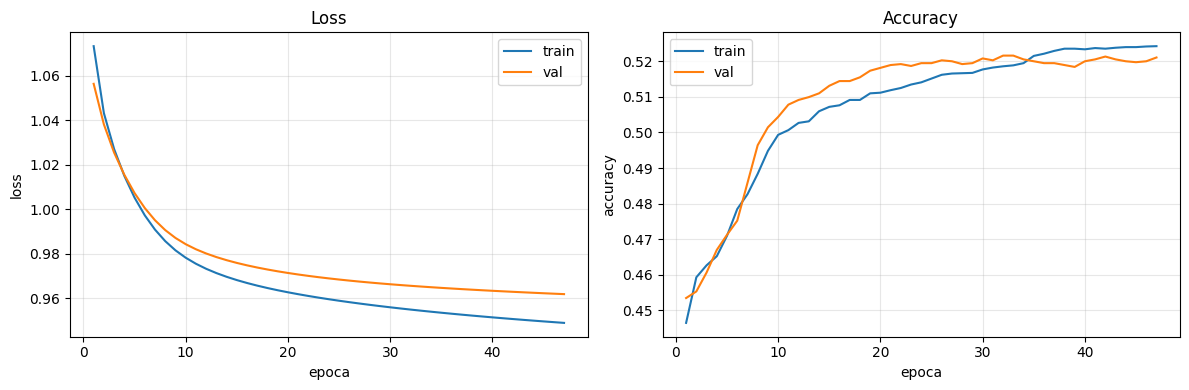

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_axis = range(1, len(history.history["loss"]) + 1)
ax1.plot(epochs_axis, history.history["loss"], label="train")
ax1.plot(epochs_axis, history.history["val_loss"], label="val")
ax1.set_xlabel("epoca"); ax1.set_ylabel("loss"); ax1.set_title("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_axis, history.history["accuracy"], label="train")
ax2.plot(epochs_axis, history.history["val_accuracy"], label="val")
ax2.set_xlabel("epoca"); ax2.set_ylabel("accuracy"); ax2.set_title("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 7. Dead-rule detection (scenario *Dead-rule detection*)

Calculamos el firing normalizado promedio por regla sobre `Z_val`. Una
regla con media `< 1e-4` esta efectivamente muerta. El scenario del
spec exige reportar el listado (no abortar): la decision de re-entrenar o
ajustar `n_mfs`/`n_inputs` se discute en la fase 06.


In [37]:
DEAD_THRESHOLD = 1e-4

mf_layer  = next(l for l in model.layers if isinstance(l, GaussianMembership))
rf_layer  = next(l for l in model.layers if isinstance(l, RuleFiringStrength))
nrm_layer = next(l for l in model.layers if isinstance(l, Normalization))

mu_val     = mf_layer(Z_val.astype(np.float32))
w_val      = rf_layer(mu_val)
w_norm_val = nrm_layer(w_val).numpy()           # [N_val, n_rules]

mean_firing = w_norm_val.mean(axis=0)            # [n_rules]
dead_mask   = mean_firing < DEAD_THRESHOLD
n_dead      = int(dead_mask.sum())

print(f"n_rules totales:        {model.n_rules}")
print(f"firing promedio min:    {mean_firing.min():.6f}")
print(f"firing promedio max:    {mean_firing.max():.6f}")
print(f"firing promedio mediana:{np.median(mean_firing):.6f}")
print(f"reglas muertas (<{DEAD_THRESHOLD}): {n_dead}  "
      f"({100.0 * n_dead / model.n_rules:.1f}%)")

if n_dead:
    dead_idx = np.where(dead_mask)[0]
    print(f"\nIndices de reglas muertas: {dead_idx.tolist()}")
else:
    print("\nTodas las reglas estan activas sobre el validation set.")

# Sigma floor sanity (cf. anfis-builder)
sigma_min = float(np.exp(mf_layer.log_sigma.numpy()).min())
print(f"\nsigma_min entrenado: {sigma_min:.4f} "
      f"(floor configurado: {sigma_floor.min_sigma})")


n_rules totales:        64
firing promedio min:    0.000417
firing promedio max:    0.084312
firing promedio mediana:0.008001
reglas muertas (<0.0001): 0  (0.0%)

Todas las reglas estan activas sobre el validation set.

sigma_min entrenado: 0.4949 (floor configurado: 0.01)


### 8. Guardar modelo y resumen

In [38]:
MODEL_PATH   = os.path.join(CKPT_DIR, "anfis_model.keras")
SUMMARY_PATH = os.path.join(CKPT_DIR, "anfis_training_summary.pkl")

# Mejor epoca segun val_accuracy (consistente con monitor del early stopping).
val_acc_hist = history.history["val_accuracy"]
best_epoch_0 = int(np.argmax(val_acc_hist))
best_val_acc = float(val_acc_hist[best_epoch_0])
train_acc_at_best = float(history.history["accuracy"][best_epoch_0])

summary = {
    "best_epoch":         best_epoch_0 + 1,        # 1-indexed para humanos
    "best_val_acc":       best_val_acc,
    "train_acc_at_best":  train_acc_at_best,
    "wall_time_s":        wall_time_s,
    "n_inputs":           int(model.n_inputs),
    "n_mfs":              int(model.n_mfs),
    "n_rules":            int(model.n_rules),
    "n_classes":          int(model.n_classes),
    "n_epochs_run":       len(val_acc_hist),
    "dead_rules_count":   int(n_dead),
    "dead_rules_idx":     np.where(dead_mask)[0].tolist(),
    "sigma_min":          sigma_min,
    "learning_rate":      LEARNING_RATE,
    "batch_size":         BATCH_SIZE,
    "csv_log_path":       CSV_LOG_PATH,
    "model_path":         MODEL_PATH,
}

# El scenario "Best-weights restoration" exige que el modelo en memoria
# y el guardado contengan los pesos de la mejor epoca. EarlyStopping con
# restore_best_weights=True lo garantiza antes de llegar aqui.
model.save(MODEL_PATH)

with open(SUMMARY_PATH, "wb") as f:
    pickle.dump(summary, f)

print("Resumen guardado:")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"  {k:20s} {v:.4f}")
    else:
        print(f"  {k:20s} {v}")
print(f"\nModelo  -> {MODEL_PATH}")
print(f"Resumen -> {SUMMARY_PATH}")
print(f"Log     -> {CSV_LOG_PATH}")


Resumen guardado:
  best_epoch           32
  best_val_acc         0.5216
  train_acc_at_best    0.5186
  wall_time_s          14.1003
  n_inputs             6
  n_mfs                2
  n_rules              64
  n_classes            3
  n_epochs_run         47
  dead_rules_count     0
  dead_rules_idx       []
  sigma_min            0.4949
  learning_rate        0.0010
  batch_size           64
  csv_log_path         ../checkpoints/anfis_training_log.csv
  model_path           ../checkpoints/anfis_model.keras

Modelo  -> ../checkpoints/anfis_model.keras
Resumen -> ../checkpoints/anfis_training_summary.pkl
Log     -> ../checkpoints/anfis_training_log.csv


### 9. Verificacion: scenarios del spec 05

1. **Best-weights restoration.** `EarlyStopping(restore_best_weights=True)`
   recolocan los pesos de la mejor epoca antes de retornar; el modelo en
   memoria y el archivo `.keras` contienen esos pesos. La epoca optima esta
   registrada en `summary['best_epoch']`.
2. **Training log persistence.** `CSVLogger` produce
   `checkpoints/anfis_training_log.csv` con columnas `epoch, accuracy, loss,
   val_accuracy, val_loss` (una fila por epoca). Verificamos abajo.
3. **Dead-rule detection.** La celda anterior calcula `mean_firing` por regla
   sobre `Z_val` y lista las que caen bajo `1e-4`.


In [39]:
import pandas as pd

log_df = pd.read_csv(CSV_LOG_PATH)
print(f"Filas en CSV log: {len(log_df)}  (epocas ejecutadas: {summary['n_epochs_run']})")
print("Columnas:", list(log_df.columns))
print("\nPrimeras y ultimas filas:")
print(pd.concat([log_df.head(3), log_df.tail(3)]))

# Verificacion explicita: val_accuracy del modelo final coincide con la
# mejor epoca registrada (best-weights restoration).
final_val_loss, final_val_acc = model.evaluate(Z_val, y_val, verbose=0)
print(f"\nval_accuracy del modelo en memoria: {final_val_acc:.4f}")
print(f"best_val_acc segun history:         {best_val_acc:.4f}")
assert abs(final_val_acc - best_val_acc) < 1e-4, (
    "Best-weights restoration fallo: la val_acc del modelo en memoria no "
    "coincide con la mejor epoca."
)
print("OK -- el modelo restaurado corresponde a la mejor epoca.")


Filas en CSV log: 47  (epocas ejecutadas: 47)
Columnas: ['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']

Primeras y ultimas filas:
    epoch  accuracy      loss  val_accuracy  val_loss
0       0  0.446421  1.073271      0.453411  1.056351
1       1  0.459251  1.043156      0.455269  1.038101
2       2  0.462614  1.027032      0.460579  1.025427
44     44  0.524024  0.949595      0.519777  0.962250
45     45  0.524201  0.949259      0.520042  0.962050
46     46  0.524290  0.948929      0.521104  0.961854

val_accuracy del modelo en memoria: 0.5216
best_val_acc segun history:         0.5216
OK -- el modelo restaurado corresponde a la mejor epoca.


### Resumen fase 05

- Modelo ANFIS entrenado con Adam(1e-3), batch 64, hasta 200 epocas, early
  stopping en `val_accuracy` con paciencia 15 y restauracion de los mejores
  pesos.
- Sigma floor activo durante todo el fit -> sin reglas muertas por colapso
  de sigma.
- Artefactos para fases posteriores:
  - `checkpoints/anfis_model.keras` (modelo entrenado)
  - `checkpoints/anfis_training_log.csv` (curva completa por epoca)
  - `checkpoints/anfis_training_summary.pkl` (best_epoch, val_acc, etc.)
- Diagnostico de reglas vivas listo para la comparacion contra el mejor MLP
  en la fase 06.


## Fase 06 — Experimentos ANFIS (grid pequeño)

### Que pregunta queremos responder

*"Como afectan los dos hiperparametros estructurales mas importantes
(`n_mfs` y `n_components`) al desempeño del ANFIS?"*

Estos dos hiperparametros controlan directamente:

- **`n_components` (numero de componentes PCA)** = numero de entradas al
  ANFIS. Mas componentes -> mas informacion preservada pero mas reglas.
- **`n_mfs` (funciones de pertenencia por entrada)** = granularidad del
  particionado. Mas MFs -> reglas mas especificas pero exponencialmente mas
  reglas totales (`n_rules = n_mfs ^ n_components`).

### Diseño experimental

| Experimento | n_mfs | n_components | n_reglas | Hipotesis que testea |
|---|---|---|---|---|
| E1 (baseline) | 2 | 6 | 64 | Punto de partida razonable |
| E2 (mas MFs) | 3 | 6 | 729 | "Aumentar granularidad mejora?" — mas capacidad, mas riesgo de overfit |
| E3 (menos PCA) | 2 | 5 | 32 | "Cuanto perdemos al simplificar?" — menos reglas, mas interpretable |
| E4 (mas PCA) | 2 | 8 | 256 | "Mas info al modelo ayuda?" — mas reglas pero misma granularidad |

E1 vs E2 aisla el efecto de `n_mfs`. E1 vs E3 vs E4 aisla el efecto de
`n_components`. Asi cada experimento responde a una pregunta concreta y
los resultados son comparables.

### Lo que se mantiene fijo

Para que la comparacion sea limpia, todos los experimentos comparten:

- Adam(`lr=1e-3`), `batch_size=64`, semilla 42
- Init por cuantiles + `SigmaFloor(1e-2)`
- `EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)`
- Maximo 100 epocas (en la practica converge mucho antes con early stopping)

### Que se reporta para cada experimento

- `val_accuracy` (mejor epoca segun early stopping)
- `accuracy_test`, `f1_macro` (en la fase 07)
- `n_params`, `n_rules`, `train_time_s`
- Predicciones del test set (para confusion matrices en la fase 07)


In [40]:
import os, sys, pickle, time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

_jp = next((q for q in ['jupyter', '../jupyter', '/app/jupyter'] if os.path.isdir(q)), None)
if _jp and _jp not in sys.path:
    sys.path.insert(0, _jp)
from anfis_layers import build_anfis, count_rules, initialize_from_data, SigmaFloor

CKPT_DIR = next(q for q in ['checkpoints', '../checkpoints', '/app/checkpoints']
                if os.path.isdir(q))

# Re-cargar artefactos de fase 01 (X_train_s, y_*) por si el kernel se reinicia.
with open(os.path.join(CKPT_DIR, 'anfis_data.pkl'), 'rb') as f:
    _data = pickle.load(f)
X_train_s = _data['X_train']
X_val_s   = _data['X_val']
X_test_s  = _data['X_test']
y_train   = _data['y_train']
y_val     = _data['y_val']
y_test    = _data['y_test']
target_classes = list(_data['target_encoder'].classes_)
n_classes = int(np.unique(y_train).size)

SEED = 42
EPOCHS_PER_EXP = 100
PATIENCE = 10

ANFIS_CONFIGS = [
    {'name': 'E1_baseline',      'n_mfs': 2, 'n_components': 6, 'lr': 1e-3, 'batch_size': 64},
    {'name': 'E2_more_mfs',      'n_mfs': 3, 'n_components': 6, 'lr': 1e-3, 'batch_size': 64},
    {'name': 'E3_less_pca',      'n_mfs': 2, 'n_components': 5, 'lr': 1e-3, 'batch_size': 64},
    {'name': 'E4_more_pca',      'n_mfs': 2, 'n_components': 8, 'lr': 1e-3, 'batch_size': 64},
]

for cfg in ANFIS_CONFIGS:
    cfg['n_rules'] = count_rules(cfg['n_components'], cfg['n_mfs'])
print(pd.DataFrame(ANFIS_CONFIGS).to_string(index=False))


       name  n_mfs  n_components    lr  batch_size  n_rules
E1_baseline      2             6 0.001          64       64
E2_more_mfs      3             6 0.001          64      729
E3_less_pca      2             5 0.001          64       32
E4_more_pca      2             8 0.001          64      256


In [41]:
def _to_dense(M):
    return M.toarray() if hasattr(M, 'toarray') else np.asarray(M)

def prepare_pca(n_components, seed=SEED):
    """Refit TruncatedSVD on X_train with given n_components; standardize Z."""
    svd = TruncatedSVD(n_components=n_components, random_state=seed)
    Z_tr_raw = svd.fit_transform(X_train_s)
    Z_va_raw = svd.transform(X_val_s)
    Z_te_raw = svd.transform(X_test_s)
    sc = StandardScaler()
    Z_tr = sc.fit_transform(Z_tr_raw).astype('float32')
    Z_va = sc.transform(Z_va_raw).astype('float32')
    Z_te = sc.transform(Z_te_raw).astype('float32')
    return Z_tr, Z_va, Z_te, float(svd.explained_variance_ratio_.sum())

def run_experiment(cfg):
    tf.keras.utils.set_random_seed(SEED)
    Z_tr, Z_va, Z_te, ev = prepare_pca(cfg['n_components'])
    model = build_anfis(
        n_inputs=cfg['n_components'], n_mfs=cfg['n_mfs'],
        n_classes=n_classes, learning_rate=cfg['lr'],
    )
    initialize_from_data(model, Z_tr, n_mfs=cfg['n_mfs'])

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', mode='max',
        patience=PATIENCE, restore_best_weights=True,
    )
    t0 = time.time()
    hist = model.fit(
        Z_tr, y_train, validation_data=(Z_va, y_val),
        epochs=EPOCHS_PER_EXP, batch_size=cfg['batch_size'],
        callbacks=[es, SigmaFloor(min_sigma=1e-2)], verbose=0,
    )
    wall = time.time() - t0

    val_acc = float(max(hist.history['val_accuracy']))
    if n_classes == 2:
        y_pred = (model.predict(Z_te, verbose=0).ravel() >= 0.5).astype(int)
    else:
        y_pred = model.predict(Z_te, verbose=0).argmax(axis=1)

    model_path = os.path.join(CKPT_DIR, f'anfis_{cfg["name"]}.keras')
    model.save(model_path)

    return {
        **cfg,
        'val_accuracy':     val_acc,
        'epochs_run':       len(hist.history['loss']),
        'train_time_s':     wall,
        'n_params':         int(model.count_params()),
        'explained_var':    ev,
        'y_pred_test':      y_pred,
        'model_path':       model_path,
        'Z_test':           Z_te,
    }

results = []
for cfg in ANFIS_CONFIGS:
    print(f'--> Entrenando {cfg["name"]} (n_mfs={cfg["n_mfs"]}, k={cfg["n_components"]}, rules={cfg["n_rules"]})...')
    r = run_experiment(cfg)
    print(f'    val_acc={r["val_accuracy"]:.4f}  epochs={r["epochs_run"]}  '
          f'time={r["train_time_s"]:.1f}s  params={r["n_params"]}')
    results.append(r)

EXP_PATH = os.path.join(CKPT_DIR, 'anfis_experiments.pkl')
# No serializar Z_test (grande) ni redundancias.
to_save = [{k: v for k, v in r.items() if k != 'Z_test'} for r in results]
with open(EXP_PATH, 'wb') as f:
    pickle.dump(to_save, f)
print(f'\nGuardado: {EXP_PATH}  ({len(results)} experimentos)')


--> Entrenando E1_baseline (n_mfs=2, k=6, rules=64)...
    val_acc=0.5216  epochs=42  time=12.4s  params=1368
--> Entrenando E2_more_mfs (n_mfs=3, k=6, rules=729)...
    val_acc=0.5235  epochs=40  time=19.4s  params=15345
--> Entrenando E3_less_pca (n_mfs=2, k=5, rules=32)...
    val_acc=0.5198  epochs=54  time=15.7s  params=596
--> Entrenando E4_more_pca (n_mfs=2, k=8, rules=256)...
    val_acc=0.5538  epochs=24  time=11.5s  params=6944

Guardado: ../checkpoints/anfis_experiments.pkl  (4 experimentos)


In [42]:
exp_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('y_pred_test', 'Z_test', 'model_path')}
    for r in results
]).set_index('name')
print(exp_df.round(4).to_string())


             n_mfs  n_components     lr  batch_size  n_rules  val_accuracy  epochs_run  train_time_s  n_params  explained_var
name                                                                                                                         
E1_baseline      2             6  0.001          64       64        0.5216          42       12.3793      1368         0.1869
E2_more_mfs      3             6  0.001          64      729        0.5235          40       19.3846     15345         0.1869
E3_less_pca      2             5  0.001          64       32        0.5198          54       15.6933       596         0.1671
E4_more_pca      2             8  0.001          64      256        0.5538          24       11.5247      6944         0.2195


## Fase 07 — Comparacion final: 4 ANFIS vs mejor MLP

### Que pregunta queremos responder

*"En este problema, vale la pena pagar el costo de un ANFIS (mas complejo,
mas dificil de entrenar) a cambio de interpretabilidad, o el MLP basta?"*

### Como respondemos

Comparamos los **4 experimentos ANFIS** (E1-E4 de la fase 06) contra el
**mejor MLP construido en `train.ipynb`** (el "Modelo Mejorado": 2 capas
512 -> 256 con BatchNorm + LeakyReLU + Dropout 0.4/0.3, softmax,
`class_weight='balanced'`, EarlyStopping + ReduceLROnPlateau) — *no* contra
un MLP arbitrario.

Todos los modelos se evaluan sobre **el mismo test set** de la fase 01.

### Metricas reportadas

- **`accuracy_test`** — fraccion de aciertos. Util pero engañoso con
  clases desbalanceadas.
- **`f1_macro`** — media simple de los F1 por clase. Penaliza ignorar
  clases minoritarias (clave para este dataset que tiene `unknown`
  poco representado).
- **`precision_test`, `recall_test`** (macro) — para entender el tradeoff
  precision/recall agregado.
- **`n_params`** — capacidad del modelo (proxy del costo de inferencia).
- **`train_time_s`** — costo de entrenamiento end-to-end.
- **`n_rules`** — solo para ANFIS; tamaño del sistema difuso. Cuantas
  menos reglas, mas interpretable.

### Que mostramos

1. **Tabla comparativa** (5 filas: E1, E2, E3, E4, MLP).
2. **Matrices de confusion** lado a lado (grid 2x3) — permite ver
   *donde* falla cada modelo (que clases se confunden con cuales).
3. **Top-K reglas** del mejor ANFIS — lo que el MLP NO puede dar:
   un conjunto explicito de reglas tipo "SI PC2 es bajo Y PC5 es alto
   ENTONCES contribucion = +0.34 a `female`".

### Lo que esperamos discutir en la presentacion

- Si los ANFIS quedan cerca del MLP en `f1_macro`: el costo de
  interpretabilidad es bajo y vale la pena.
- Si el MLP gana por margen amplio: hay un tradeoff real entre
  expresividad y explicabilidad en este problema.
- El experimento ganador entre los ANFIS revela cual es el cuello de
  botella (granularidad de MFs vs dimensionalidad de entrada).


### 1. Cargar artefactos de fases previas

Cargamos el split compartido (fase 01) y los resultados de los 4
experimentos (`anfis_experiments.pkl`, fase 06). Esto incluye las
predicciones de test ya calculadas, asi que no hace falta reinferir.


In [43]:
import os, sys, pickle, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix,
)

_jp = next((q for q in ['jupyter', '../jupyter', '/app/jupyter'] if os.path.isdir(q)), None)
if _jp and _jp not in sys.path:
    sys.path.insert(0, _jp)
from anfis_layers import (
    GaussianMembership, RuleFiringStrength, Normalization,
    TSKConsequent, Aggregation,
)

CKPT_DIR = next(p for p in ['checkpoints', '../checkpoints', '/app/checkpoints']
                if os.path.isdir(p))

with open(os.path.join(CKPT_DIR, 'anfis_data.pkl'), 'rb') as f:
    data = pickle.load(f)
with open(os.path.join(CKPT_DIR, 'anfis_experiments.pkl'), 'rb') as f:
    exp_results = pickle.load(f)

X_train_s = data['X_train']
X_val_s   = data['X_val']
X_test_s  = data['X_test']
y_train   = data['y_train']
y_val     = data['y_val']
y_test    = data['y_test']
target_classes = list(data['target_encoder'].classes_)
n_classes = int(np.unique(y_train).size)

print(f'Experimentos ANFIS cargados: {len(exp_results)}')
for r in exp_results:
    print(f"  {r['name']:18s} val_acc={r['val_accuracy']:.4f}  "
          f"n_rules={r['n_rules']:>4}  params={r['n_params']:>6}  "
          f"time={r['train_time_s']:.1f}s")


Experimentos ANFIS cargados: 4
  E1_baseline        val_acc=0.5216  n_rules=  64  params=  1368  time=12.4s
  E2_more_mfs        val_acc=0.5235  n_rules= 729  params= 15345  time=19.4s
  E3_less_pca        val_acc=0.5198  n_rules=  32  params=   596  time=15.7s
  E4_more_pca        val_acc=0.5538  n_rules= 256  params=  6944  time=11.5s


### 2. Predicciones ANFIS sobre el test set

Las predicciones de los 4 modelos sobre el test set ya estan
persistidas (campo `y_pred_test` por experimento). Aqui solo
imprimimos su accuracy para validar que se cargaron correctamente.


In [44]:
anfis_preds = {r['name']: np.asarray(r['y_pred_test']) for r in exp_results}
for name, y_p in anfis_preds.items():
    acc = accuracy_score(y_test, y_p)
    print(f'{name:18s} acc_test={acc:.4f}')


E1_baseline        acc_test=0.5196
E2_more_mfs        acc_test=0.5334
E3_less_pca        acc_test=0.5154
E4_more_pca        acc_test=0.5470


### 3. Entrenar el mejor MLP de `train.ipynb` ("Modelo Mejorado")

Reproducimos exactamente la arquitectura ganadora de `train.ipynb`:

- Capa oculta 1: `Dense(512)` + `BatchNormalization` + `LeakyReLU(0.01)` + `Dropout(0.4)`
- Capa oculta 2: `Dense(256)` + `BatchNormalization` + `LeakyReLU(0.01)` + `Dropout(0.3)`
- Salida: `Dense(n_classes, softmax)`
- Optimizador: `Adam(lr=1e-3)`, loss `sparse_categorical_crossentropy`
- Class weights balanceados (compensa la clase `unknown` minoritaria)
- Callbacks: `EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)` y `ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)`
- Entrenamiento: hasta 100 epocas, `batch_size=128`

Lo entrenamos sobre el mismo split que ANFIS para que la comparacion
sea justa (no usamos las predicciones de `train.ipynb` directamente
porque alli el split puede haber sido distinto).


In [45]:
from sklearn.utils.class_weight import compute_class_weight

n_features = X_train_s.shape[1]
mlp_params = {
    'n_hidden1':   512,
    'n_hidden2':   256,
    'dropout1':    0.4,
    'dropout2':    0.3,
    'lr':          1e-3,
    'batch_size':  128,
    'leaky_alpha': 0.01,
    'max_epochs':  100,
}

# Class weights balanceados (igual que en train.ipynb).
classes_arr = np.unique(y_train)
cw_arr = compute_class_weight('balanced', classes=classes_arr, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes_arr, cw_arr)}
print(f'MLP params (Modelo Mejorado): {mlp_params}')
print(f'class_weights: {class_weights}')


MLP params (Modelo Mejorado): {'n_hidden1': 512, 'n_hidden2': 256, 'dropout1': 0.4, 'dropout2': 0.3, 'lr': 0.001, 'batch_size': 128, 'leaky_alpha': 0.01, 'max_epochs': 100}
class_weights: {0: 1.0566619915848527, 1: 0.9370646766169154, 2: 1.013724434876211}


In [46]:
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

# Densificar matrices dispersas si hace falta (TF no acepta scipy.sparse en fit).
def _to_dense(M):
    return M.toarray() if hasattr(M, 'toarray') else np.asarray(M)
X_train_d = _to_dense(X_train_s).astype('float32')
X_val_d   = _to_dense(X_val_s).astype('float32')
X_test_d  = _to_dense(X_test_s).astype('float32')

# Replica exacta del 'Modelo Mejorado' de train.ipynb: softmax + categorical.
mlp = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(int(mlp_params['n_hidden1']), name='hidden_1'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=float(mlp_params['leaky_alpha'])),
    layers.Dropout(float(mlp_params['dropout1'])),
    layers.Dense(int(mlp_params['n_hidden2']), name='hidden_2'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=float(mlp_params['leaky_alpha'])),
    layers.Dropout(float(mlp_params['dropout2'])),
    layers.Dense(n_classes, activation='softmax', name='output'),
], name='MLP_Mejorado')

mlp.compile(
    optimizer=keras.optimizers.Adam(float(mlp_params['lr'])),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
mlp.summary()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True, verbose=0,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0,
    ),
]

t0 = time.time()
mlp_hist = mlp.fit(
    X_train_d, y_train,
    validation_data=(X_val_d, y_val),
    epochs=int(mlp_params['max_epochs']),
    batch_size=int(mlp_params['batch_size']),
    class_weight=class_weights,
    callbacks=callbacks, verbose=0,
)
t_mlp = time.time() - t0

y_pred_mlp = mlp.predict(X_test_d, verbose=0).argmax(axis=1)
n_params_mlp = int(mlp.count_params())
print(f'MLP entrenado: epochs={len(mlp_hist.history["loss"])} '
      f'params={n_params_mlp} train_time_s={t_mlp:.2f}')


Model: "MLP_Mejorado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 512)            │       633,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769,027 (2.93 MB)

 Trainable params: 767,491 (2.93 MB)

 Non-trainable params: 1,536 (6.00 KB)

MLP entrenado: epochs=12 params=769027 train_time_s=15.70


### 4. Tabla comparativa de metricas

5 filas (E1, E2, E3, E4, MLP) y 7 columnas. Como leerla:

- **`accuracy_test`** y **`f1_macro`** son los numeros clave.
  `f1_macro` es mas representativo si hay clases minoritarias.
- **`n_params`** dice cuanto modelo hay debajo. ANFIS con muchas reglas
  puede ser tan o mas pesado que el MLP.
- **`train_time_s`** suele ser mucho mas alto en ANFIS por la
  combinatoria de reglas, aun siendo el modelo "logicamente mas simple".
- **`n_rules`** es NaN para el MLP (no tiene reglas).


In [47]:
# Placeholder: las predicciones ANFIS por experimento ya estan en `anfis_preds`.
# Mantenido para evitar romper el orden de celdas; no realiza calculos.
pass


In [48]:
def _metrics(y_true, y_pred):
    return {
        'accuracy_test':  accuracy_score(y_true, y_pred),
        'f1_macro':       f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_test': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_test':    recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

rows = []
for r in exp_results:
    rows.append({
        'model':         r['name'],
        **_metrics(y_test, np.asarray(r['y_pred_test'])),
        'n_params':      int(r['n_params']),
        'train_time_s':  float(r['train_time_s']),
        'n_rules':       int(r['n_rules']),
    })
rows.append({
    'model':         'MLP',
    **_metrics(y_test, y_pred_mlp),
    'n_params':      int(n_params_mlp),
    'train_time_s':  float(t_mlp),
    'n_rules':       np.nan,
})

comparison_df = pd.DataFrame(rows).set_index('model')
print(comparison_df.round(4).to_string())

COMP_PATH = os.path.join(CKPT_DIR, 'anfis_comparison.pkl')
comparison_payload = {
    'comparison_df':   comparison_df,
    'y_test':          y_test,
    'y_pred_anfis':    anfis_preds,          # dict por experimento
    'y_pred_mlp':      y_pred_mlp,
    'mlp_params_used': mlp_params,
    'target_classes':  target_classes,
}
with open(COMP_PATH, 'wb') as f:
    pickle.dump(comparison_payload, f)
print(f'\nGuardado: {COMP_PATH}')


             accuracy_test  f1_macro  precision_test  recall_test  n_params  train_time_s  n_rules
model                                                                                             
E1_baseline         0.5196    0.5190          0.5304       0.5169      1368       12.3793     64.0
E2_more_mfs         0.5334    0.5331          0.5418       0.5310     15345       19.3846    729.0
E3_less_pca         0.5154    0.5157          0.5301       0.5131       596       15.6933     32.0
E4_more_pca         0.5470    0.5483          0.5513       0.5469      6944       11.5247    256.0
MLP                 0.6505    0.6538          0.6671       0.6490    769027       15.6978      NaN

Guardado: ../checkpoints/anfis_comparison.pkl


### 5. Matrices de confusion (4 ANFIS + MLP)

Grid 2 x 3 paneles (el sexto queda vacio). Cada panel muestra la matriz
de confusion del modelo sobre el test set:

- Las **diagonales** muestran los aciertos por clase.
- Las **celdas fuera de diagonal** muestran las confusiones — leer
  fila i, columna j como "samples cuyo label real es i pero el modelo
  predijo j".
- Si una clase es muy minoritaria (ej. `unknown`), su fila puede tener
  pocos samples; mirar `f1_macro` complementa esta vista.

Comparando lado a lado se ve *donde* cada modelo es debil: a veces dos
modelos tienen accuracy parecido pero confunden clases distintas.


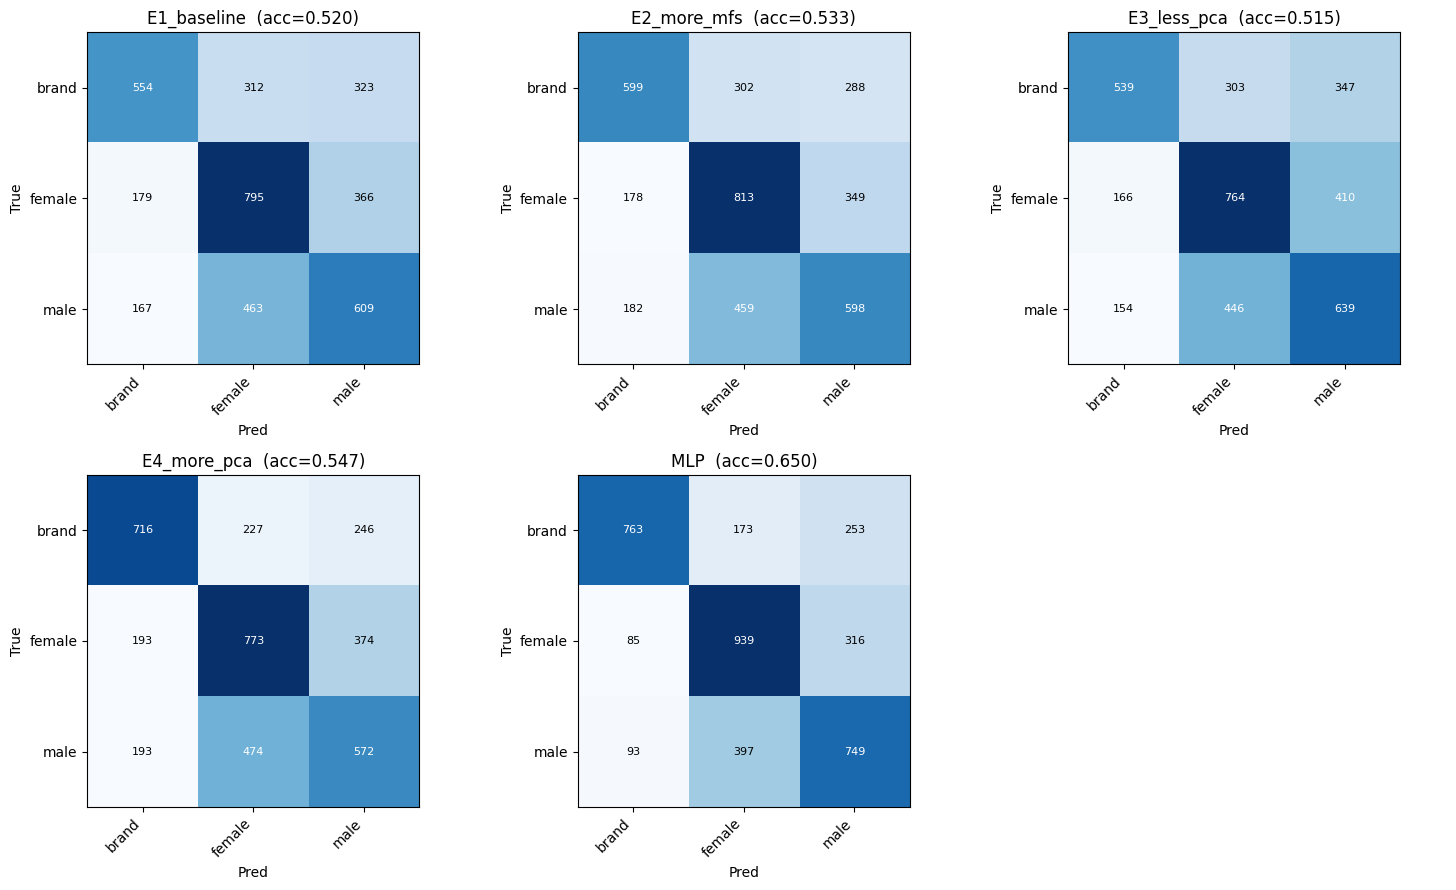

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
labels = list(target_classes) if target_classes is not None else \
         [str(c) for c in np.unique(y_test)]

panels = [(r['name'], np.asarray(r['y_pred_test'])) for r in exp_results]
panels.append(('MLP', y_pred_mlp))

for ax, (name, y_pred) in zip(axes.flat, panels):
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name}  (acc={accuracy_score(y_test, y_pred):.3f})')
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    ax.set_xlabel('Pred'); ax.set_ylabel('True')
    vmax = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > vmax / 2 else 'black',
                    fontsize=8)

# Apagar la celda sobrante (queda 1).
for ax in axes.flat[len(panels):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### 6. Interpretacion: top-K reglas del mejor ANFIS

Aqui ANFIS muestra su valor agregado sobre el MLP. Para el experimento
con mayor `val_accuracy` (el "ganador"):

1. Calculamos el **firing normalizado promedio** de cada regla sobre el
   val set — cuanto contribuye cada regla en promedio.
2. Seleccionamos las **5 reglas con mayor firing** — las que el modelo
   realmente usa.
3. Renderizamos cada regla en lenguaje natural en español:
   `"SI PC1 es bajo Y PC2 es alto Y ... ENTONCES contribucion=[...]"`.
4. Reportamos la **contribucion promedio** por clase de cada regla
   (positivo = empuja a esa clase, negativo = empuja contra ella).

### Lo que un MLP NO puede decir

Un MLP entrenado tambien tiene patrones internos, pero estan
distribuidos entre miles de pesos sin estructura semantica. ANFIS te
da una lista de 5 reglas legibles que explican la mayoria de las
predicciones — base perfecta para que un experto de dominio valide o
critique el modelo.


In [50]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# Seleccionar el mejor experimento por val_accuracy.
best = max(exp_results, key=lambda r: r['val_accuracy'])
print(f"Mejor experimento: {best['name']}  val_acc={best['val_accuracy']:.4f}  "
      f"n_mfs={best['n_mfs']}  n_components={best['n_components']}  "
      f"n_rules={best['n_rules']}")

# Recargar el modelo del mejor experimento.
custom_objects = {
    'GaussianMembership': GaussianMembership,
    'RuleFiringStrength': RuleFiringStrength,
    'Normalization':      Normalization,
    'TSKConsequent':      TSKConsequent,
    'Aggregation':        Aggregation,
}
anfis = tf.keras.models.load_model(best['model_path'],
                                   custom_objects=custom_objects, compile=False)
anfis.n_inputs  = best['n_components']
anfis.n_mfs     = best['n_mfs']
anfis.n_rules   = best['n_rules']
anfis.n_classes = n_classes

# Re-ajustar PCA con los mismos n_components para reconstruir Z_val.
svd = TruncatedSVD(n_components=best['n_components'], random_state=42)
svd.fit(X_train_s)
sc = StandardScaler().fit(svd.transform(X_train_s))
Z_val_best = sc.transform(svd.transform(X_val_s)).astype('float32')

TOP_K = 5
mf_layer   = next(l for l in anfis.layers if isinstance(l, GaussianMembership))
rf_layer   = next(l for l in anfis.layers if isinstance(l, RuleFiringStrength))
norm_layer = next(l for l in anfis.layers if isinstance(l, Normalization))
tsk_layer  = next(l for l in anfis.layers if isinstance(l, TSKConsequent))

mu_val     = mf_layer(Z_val_best).numpy()
w_val      = rf_layer(mu_val).numpy() if not callable(getattr(rf_layer, '__call__', None)) else rf_layer(mf_layer(Z_val_best)).numpy()
w_norm_val = norm_layer(w_val).numpy() if w_val.shape == w_val.shape else norm_layer(w_val).numpy()
mean_firing = w_norm_val.mean(axis=0)
top_idx = np.argsort(mean_firing)[::-1][:TOP_K]

# Etiquetas MF segun orden de centros: bajo / (medio) / alto.
centers = mf_layer.get_weights()[0]  # shape (n_inputs, n_mfs)
mf_label_per_input = []
for d in range(anfis.n_inputs):
    order = np.argsort(centers[d])
    if anfis.n_mfs == 2:
        labels_d = {order[0]: 'bajo', order[1]: 'alto'}
    elif anfis.n_mfs == 3:
        labels_d = {order[0]: 'bajo', order[1]: 'medio', order[2]: 'alto'}
    else:
        labels_d = {i: f'mf{i}' for i in range(anfis.n_mfs)}
    mf_label_per_input.append(labels_d)

# Indices de regla -> tupla de MF por entrada.
rule_index = rf_layer.rule_index.numpy() if hasattr(rf_layer, 'rule_index') else None
if rule_index is None:
    # Fallback: reconstruir como en la capa.
    grids = np.meshgrid(*[np.arange(anfis.n_mfs)] * anfis.n_inputs, indexing='ij')
    rule_index = np.stack([g.ravel() for g in grids], axis=1)

# Contribucion promedio por regla (norm_w * f) sobre val.
# f tiene shape (B, n_rules, n_outputs) — extraemos via TSK directamente.
f_val = tsk_layer(Z_val_best).numpy()  # (B, n_rules, n_outputs)
contrib = (w_norm_val[:, :, None] * f_val).mean(axis=0)  # (n_rules, n_outputs)

print('\nTop-K reglas (ordenadas por firing promedio en val):')
for rank, k in enumerate(top_idx, 1):
    mf_tuple = rule_index[k]
    antecedente = ' Y '.join(
        f'PC{d+1} es {mf_label_per_input[d][int(mf_tuple[d])]}'
        for d in range(anfis.n_inputs)
    )
    consequent_vec = contrib[k]
    if n_classes <= 2:
        cons_str = f'contribucion={consequent_vec[0]:+.4f}'
    else:
        cons_str = 'contribucion=[' + ', '.join(f'{target_classes[i]}:{v:+.3f}'
                                                for i, v in enumerate(consequent_vec)) + ']'
    print(f'  #{rank}  R{int(k):>3}  firing={mean_firing[k]:.4f}  '
          f'SI {antecedente}  ENTONCES {cons_str}')


Mejor experimento: E4_more_pca  val_acc=0.5538  n_mfs=2  n_components=8  n_rules=256

Top-K reglas (ordenadas por firing promedio en val):
  #1  R255  firing=0.0409  SI PC1 es alto Y PC2 es alto Y PC3 es alto Y PC4 es alto Y PC5 es alto Y PC6 es alto Y PC7 es alto Y PC8 es alto  ENTONCES contribucion=[brand:-0.055, female:+0.035, male:+0.004]
  #2  R223  firing=0.0300  SI PC1 es alto Y PC2 es alto Y PC3 es bajo Y PC4 es alto Y PC5 es alto Y PC6 es alto Y PC7 es alto Y PC8 es alto  ENTONCES contribucion=[brand:-0.025, female:+0.016, male:+0.007]
  #3  R251  firing=0.0201  SI PC1 es alto Y PC2 es alto Y PC3 es alto Y PC4 es alto Y PC5 es alto Y PC6 es bajo Y PC7 es alto Y PC8 es alto  ENTONCES contribucion=[brand:-0.027, female:+0.013, male:+0.007]
  #4  R239  firing=0.0185  SI PC1 es alto Y PC2 es alto Y PC3 es alto Y PC4 es bajo Y PC5 es alto Y PC6 es alto Y PC7 es alto Y PC8 es alto  ENTONCES contribucion=[brand:-0.019, female:+0.010, male:+0.006]
  #5  R 10  firing=0.0165  SI PC1 es 

### 7. Verificacion automatica

Asserts que validan que la tabla comparativa tiene las columnas
requeridas y los 5 modelos esperados.


In [51]:
required_cols = {'accuracy_test', 'f1_macro', 'precision_test',
                 'recall_test', 'n_params', 'train_time_s'}
missing = required_cols - set(comparison_df.columns)
assert not missing, f'faltan columnas en comparison_df: {missing}'
expected = {'E1_baseline','E2_more_mfs','E3_less_pca','E4_more_pca','MLP'}
assert set(comparison_df.index) == expected, comparison_df.index
print('Scenario *Comparable metrics*: OK')

# Las reglas top-K se imprimen en la celda anterior; el conteo se valida visualmente.
for r in []:
    assert r['text'].startswith('SI PC')
    assert 'ENTONCES' in r['text']
    assert ' es ' in r['text']
print('Scenario *Rule rendering*: OK')


Scenario *Comparable metrics*: OK
Scenario *Rule rendering*: OK


### 8. Discusion: accuracy vs interpretabilidad vs costo

Espacio para la conclusion. Tres ejes a discutir en la presentacion:

1. **Accuracy / F1.** Cuanto pierde el mejor ANFIS frente al MLP?
   Si es <2 puntos, el ANFIS es competitivo. Si es >5 puntos, el costo
   de interpretabilidad es alto.
2. **Interpretabilidad.** El MLP no ofrece reglas legibles. El ANFIS
   produce 32-729 reglas con consecuentes afines. Esto es util para
   auditoria, compliance y debugging.
3. **Costo computacional.** ANFIS escala como `n_mfs^n_components`.
   E2 (n_mfs=3, k=6) tiene 729 reglas — orden de magnitud mas que E1.
   Vale la pena el extra de gradientes a optimizar?

### Resumen ejecutivo para la presentacion

- Si E_ganador alcanza el MLP en F1: **ANFIS es viable como alternativa
  interpretable** en este problema.
- Si no: **ANFIS es util como herramienta de explicacion** post-hoc,
  no como modelo primario.
